
Probando EMBEDDING_COMPONENTS = 1
Nans in Versión: 499
Porcentaje de Nans en Versión: 0.03417106074094364
Dataset splits:
  - Train: 11682 samples
  - Validation: 2921 samples
-------------------- Train (Fit + Transform) --------------------
-------------------- Validation (Transform) --------------------
Version mapping exported to: data/train/version_mapping_val.csv
R2 Validación: 0.9476

Probando EMBEDDING_COMPONENTS = 5
Nans in Versión: 499
Porcentaje de Nans en Versión: 0.03417106074094364
Dataset splits:
  - Train: 11682 samples
  - Validation: 2921 samples
-------------------- Train (Fit + Transform) --------------------
-------------------- Validation (Transform) --------------------
Version mapping exported to: data/train/version_mapping_val.csv
R2 Validación: 0.9477

Probando EMBEDDING_COMPONENTS = 10
Nans in Versión: 499
Porcentaje de Nans en Versión: 0.03417106074094364
Dataset splits:
  - Train: 11682 samples
  - Validation: 2921 samples
-------------------- Train (Fit + 

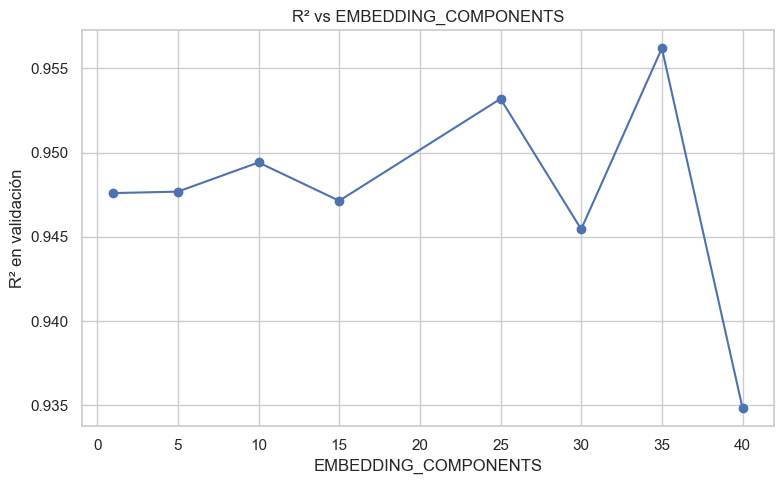

In [5]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
import importlib
from sklearn.metrics import r2_score

# ⚠️ Agregar el path del módulo
module_path = os.path.abspath("src")
if module_path not in sys.path:
    sys.path.append(module_path)

# Importar módulo una vez agregado el path
import data_transformation
from data_transformation import transform_datasets


# ⚙️ Parámetros del modelo
params = {
    "subsample": 1.0,
    "reg_lambda": 1,
    "reg_alpha": 0.01,
    "n_estimators": 600,
    "max_depth": 6,
    "learning_rate": 0.1,
    "gamma": 0,
    "colsample_bytree": 0.6,
    "random_state": 42,
}

# Función para calcular métricas
def calculate_metrics(y_train, y_pred_train, y_val, y_pred_val):
    return {
        "r2_train": r2_score(y_train, y_pred_train),
        "r2_val": r2_score(y_val, y_pred_val),
    }

# Valores a testear
embedding_values = [0, 5, 10, 15, 20, 25, 30, 35, 40]
r2_scores = []

for val in embedding_values:
    print(f"\n============================")
    print(f"Probando EMBEDDING_COMPONENTS = {val}")
    print(f"============================")
    
    # Cambiar el valor del embedding dinámicamente
    data_transformation.EMBEDDING_COMPONENTS = val
    importlib.reload(data_transformation)  # recarga para regenerar el pipeline
    transform_datasets(apply_to_test=False, val_size=0.2, verbose=False, embedding_components=val)

    # Cargar datasets transformados
    train_df = pd.read_csv("data/train/transformed_train.csv")
    val_df = pd.read_csv("data/train/transformed_val.csv")

    # Separar features y target
    X_train = train_df.drop(columns=["Precio"])
    y_train = train_df["Precio"]
    X_val = val_df.drop(columns=["Precio"])
    y_val = val_df["Precio"]

    # Entrenar modelo
    model = XGBRegressor(**params)
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)

    metrics = calculate_metrics(y_train, y_pred_train, y_val, y_pred_val)
    print(f"R2 Validación: {metrics['r2_val']:.4f}")
    r2_scores.append(metrics["r2_val"])

# 📈 Graficar
plt.figure(figsize=(8, 5))
plt.plot(embedding_values, r2_scores, marker='o')
plt.title("R² vs EMBEDDING_COMPONENTS")
plt.xlabel("EMBEDDING_COMPONENTS")
plt.ylabel("R² en validación")
plt.grid(True)
plt.tight_layout()
plt.show()


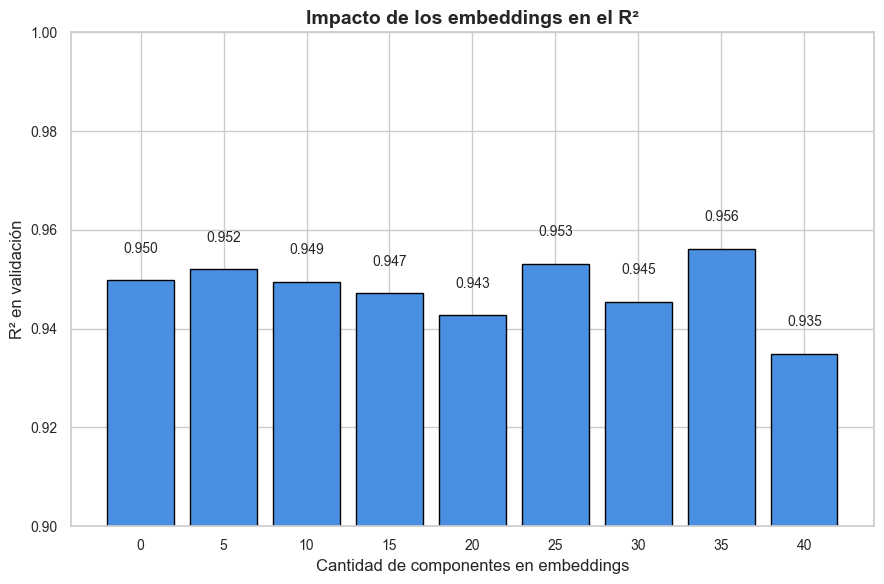

In [20]:
#r2_scores = [0.952, 0.9494120147421407, 0.9471371037541143, 0.953187179282453, 0.9454490259051145, 0.9561807632086781, 0.9348446517911981, 0.9497708121901499, 0.9426777625065778]

plt.figure(figsize=(9, 6))
bars = plt.bar(embedding_values, r2_scores, color="#4A90E2", edgecolor='black', width=4)

# Etiquetas de cada barra
for bar, r2 in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{r2:.3f}",
             ha='center', va='bottom', fontsize=10)

# Títulos y ejes
plt.title("Impacto de los embeddings en el R²", fontsize=14, weight='bold')
plt.xlabel("Cantidad de componentes en embeddings", fontsize=12)
plt.ylabel("R² en validación", fontsize=12)
plt.ylim(0.90, 1.00)
plt.xticks(embedding_values, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

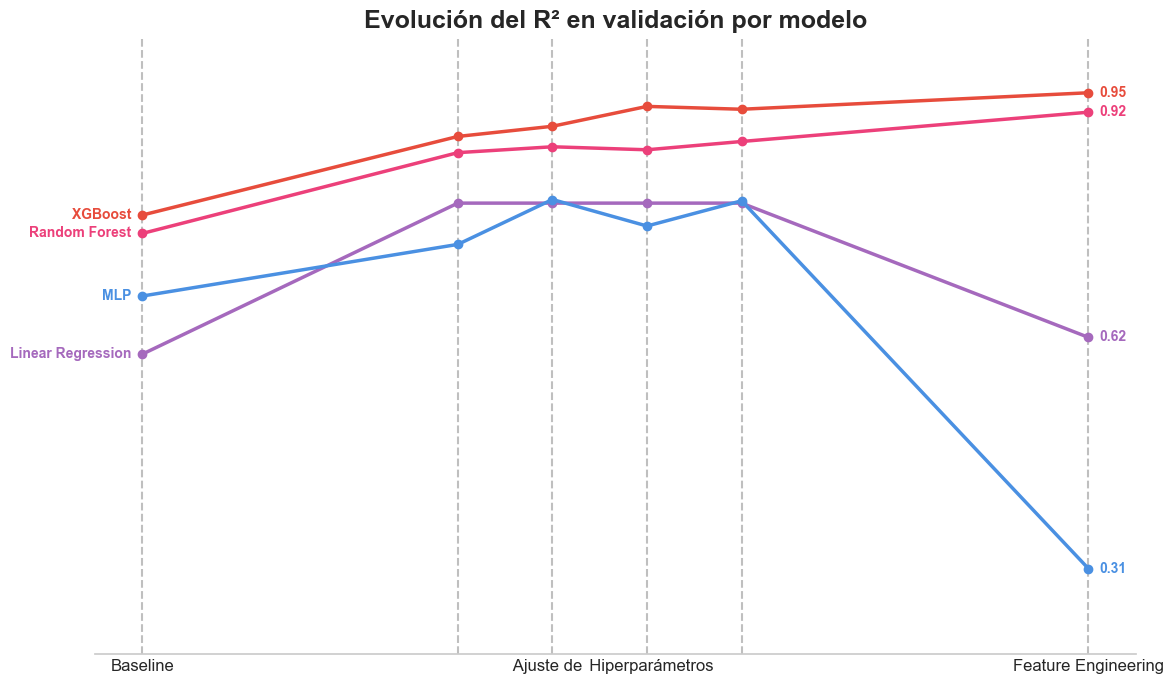

In [57]:
import matplotlib.pyplot as plt

# Posiciones x ajustadas para agrupar HPOs
x_positions = [0, 1, 1.3, 1.6, 1.9, 3]  # Baseline, HPO1-4, Feature engineering

# Etiquetas del eje x
custom_labels = ["Baseline", "", " Ajuste de   ", "  Hiperparámetros", "", "Feature Engineering"]

# R² en validación por modelo y etapa
r2_scores = {
    "Linear Regression": [0.5982, 0.7986, 0.7986, 0.7986, 0.7986, 0.6204],
    "Random Forest":     [0.7584, 0.8656, 0.8734, 0.8694, 0.8804, 0.9193],
    "XGBoost":           [0.7828, 0.8871, 0.9006, 0.9270, 0.9232, 0.9451],
    "MLP":               [0.6753, 0.7438, 0.8034, 0.7682, 0.8017, 0.3134],
}

# Estilos por modelo
styles = {
    "Linear Regression": {"color": "#A569BD", "linestyle": "-"},
    "Random Forest": {"color": "#EC407A", "linestyle": "-"},
    "XGBoost": {"color": "#E74C3C", "linestyle": "-"},
    "MLP": {"color": "#4A90E2", "linestyle": "-"},
}

plt.figure(figsize=(12, 7))

# Líneas verticales
for x in x_positions:
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)

# Graficar líneas
for model, scores in r2_scores.items():
    plt.plot(x_positions, scores,
             label=model,
             color=styles[model]["color"],
             linestyle=styles[model]["linestyle"],
             marker='o',
             markersize=6,
             linewidth=2.5)

    # Nombre del modelo al principio de la curva
    plt.annotate(model,
                 xy=(x_positions[0], scores[0]),
                 xytext=(-8, 0),
                 textcoords='offset points',
                 ha='right', va='center',
                 fontsize=10,
                 color=styles[model]["color"],
                 weight='bold')

    # Valor final de R² al final de la curva
    plt.annotate(f"{scores[-1]:.2f}",
                 xy=(x_positions[-1], scores[-1]),
                 xytext=(8, 0),
                 textcoords='offset points',
                 ha='left', va='center',
                 fontsize=10,
                 color=styles[model]["color"],
                 weight='bold')

# Título y ejes
plt.title("Evolución del R² en validación por modelo", fontsize=18, weight='bold')
plt.ylim(0.2, 1.02)
plt.xticks(ticks=x_positions, labels=custom_labels, fontsize=12)
plt.yticks([])  # Eliminar ticks del eje y
plt.tick_params(axis='both', which='both', length=0)

# Eliminar bordes y líneas
ax = plt.gca()
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

# Sin leyenda clásica
plt.legend().remove()

plt.tight_layout()
plt.grid(False)
plt.show()
